In [1]:
import sys
import os

# Ajoute le dossier racine au path pour pouvoir importer 'samplers'
# On remonte d'un niveau car le notebook est dans le dossier 'notebooks/'
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from samplers.base import SamplerResult

# Style des graphiques
sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
import sys
import os
sys.path.append('..') # Accède au dossier parent

import main # Importe ton fichier main.py

# Maintenant tu peux utiliser les fonctions de main.py
y_obs = main.simulate_ma2([0.6, 0.2])
res_gold = main.run_rwmh(y_obs, n_iter=2000, proposal_scale=0.1)

RWMH: 100%|██████████| 2000/2000 [00:00<00:00, 23612.99it/s]


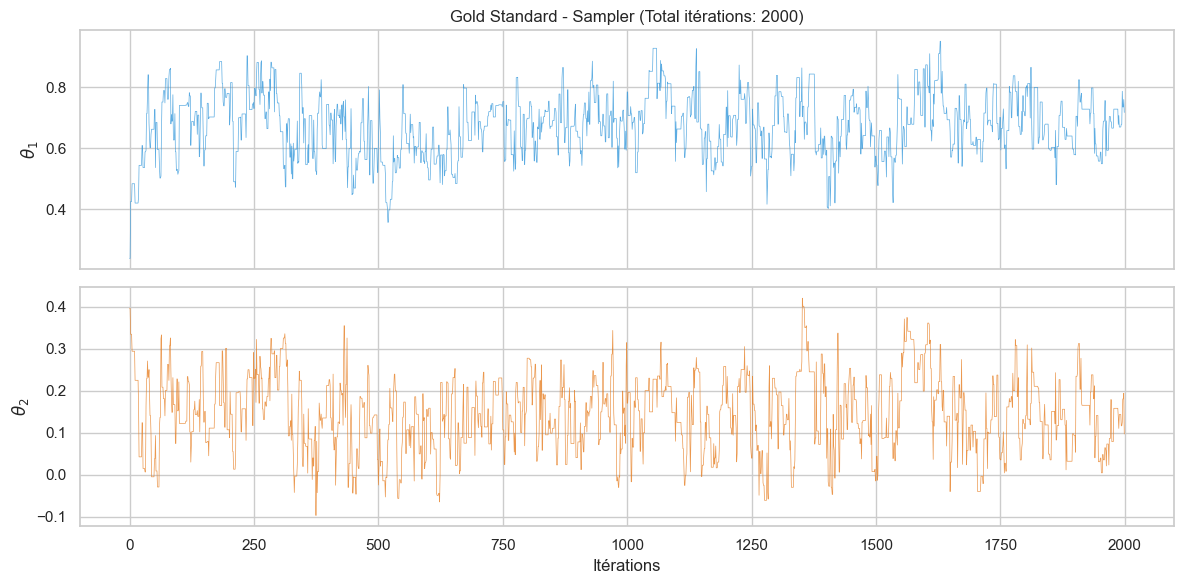

In [6]:
def plot_traces(result: SamplerResult, title="Analyse de Convergence"):
    # On essaie d'abord de prendre la chaîne complète (avec burn-in)
    # Si elle n'existe pas, on prend les samples finaux
    samples = result.diagnostics.get("full_chain", result.samples)
    
    if len(samples) == 0:
        print(f"Erreur : Aucun échantillon à tracer pour {title}. Vérifiez n_iter et burnin.")
        return

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    
    # Trace theta 1
    axes[0].plot(samples[:, 0], color='#3498db', alpha=0.8, lw=0.5)
    axes[0].set_ylabel(r"$\theta_1$")
    algo_name = result.diagnostics.get('algorithm', 'Sampler')
    axes[0].set_title(f"{title} - {algo_name} (Total itérations: {len(samples)})")
    
    # Trace theta 2
    axes[1].plot(samples[:, 1], color='#e67e22', alpha=0.8, lw=0.5)
    axes[1].set_ylabel(r"$\theta_2$")
    axes[1].set_xlabel("Itérations")
    
    # Si on affiche la full_chain, on peut dessiner une ligne pour montrer où finit le burn-in
    burnin = result.diagnostics.get("burnin", 0)
    if burnin > 0 and burnin < len(samples):
        axes[0].axvline(burnin, color='red', linestyle='--', alpha=0.5, label='Fin Burn-in')
        axes[1].axvline(burnin, color='red', linestyle='--', alpha=0.5)
        axes[0].legend()

    plt.tight_layout()
    plt.show()

plot_traces(res_gold, "Gold Standard")